### 1. Introducción 

El modelo principal de referencia en el sector bancario para Application Scoring es la **Regresión Logística con transformación WoE**. Su adopción está respaldada por las guías de la EBA (European Banking Authority) sobre modelos IRB (Internal Ratings-Based), y su
interpretabilidad directa facilita la validación regulatoria.

El objetivo de esta fase es construir un **benchmark comparativo**: entrenar modelos alternativos y evaluar si ofrecen una capacidad discriminante superior, manteniendo la interpretabilidad.

#### 1.1 Métodos elegidos para realizar el benchmark.

He seleccionado modelos de Gradient Boosting por las siguientes razones:
1. **Rendimiento empírico superior** en datos tabulares financieros, validado ampliamente en la literatura académica y en competiciones de scoring crediticio.
3. **Robustez ante outliers y variables asimétricas**, características predominantes en el dataset HMEQ identificadas durante el EDA.
4. **Gestión nativa de missing values** en LightGBM, evitando decisiones de imputación que podrían introducir sesgo.

Se entrenan dos implementaciones para validar la estabilidad de resultados:
- **LightGBM** : optimizado en memoria y velocidad, gestiona missing values de forma nativa.
- **XGBoost** : implementación clásica ampliamente auditada en entornos bancarios, requiere imputación previa de missing values.

Por último, en relación a la evaluación, se empleán las mismas métricas que la Regresión Logística, permitiendo una comparación homogénea: AUC-ROC, KS, Gini y Brier Score.

#### 1.2 Métodos descartados

He descartado el método Random Forest de la familia bagging por un menor rendimiento que boosting en datos tabulares financieros con relaciones asimétricas y variables con alta correlación.   
Las Redes neuronales actua como  un "caja negra" sin beneficio claro sobre boosting en datasets de tamaño moderado. Esto supone una difícil defensa ante regulador.  
Entre los métodos Kernel, SVM no produce probabilidades calibradas de forma directa.  Esta diseñado para clasificación binaria dura, no para scoring continuo.  
KNN es muy sensible a la escala y a la dimensionalidad. No hay capacidad de extrapolación.   

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

### 2. Carga de datos

In [2]:
# Cargar el dataset y hacer una copia
hmeq = pd.read_csv('../data/raw/hmeq.csv')
hmeq_prep_2 = hmeq.copy()

### 3. Pipeline de preprocesamiento y modelización

#### 3.1 Separación train/test

In [3]:
# train y test split
X = hmeq_prep_2.drop(columns="BAD")
y = hmeq_prep_2["BAD"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123, stratify=y)    

In [4]:
print(f"Total : {len(X)}")
print(f"Train : {len(X_train)}")
print(f"Test: {len(X_test)}")
print(f"Proporción de defaults):")
print(f"Total : {y.mean():.3f}")
print(f"Train : {y_train.mean():.3f}")
print(f"Test  : {y_test.mean():.3f}")

Total : 5960
Train : 4172
Test: 1788
Proporción de defaults):
Total : 0.199
Train : 0.199
Test  : 0.200


#### 3.2 Pipeline de preprocesamiento — ColumnTransformer

El preprocesamiento se implementa mediante un ColumnTransformer
Se definen tres grupos de variables:

**Variables numéricas para LightGBM:**
Creación de CLTV, cap en 2.55 y eliminación de MORTDUE y VALUE.
LightGBM gestiona missing values de forma nativa — no se imputan.

**Variables numéricas para XGBoost:**
Idéntico tratamiento más imputación por mediana.
XGBoost no gestiona missing values nativamente.

**Variables categóricas (ambos modelos):**
REASON y JOB — missing como categoría explícita + OrdinalEncoder.
Se usa OrdinalEncoder en lugar de LabelEncoder porque es compatible
con el pipeline de scikit-learn.

In [5]:
from sklearn.pipeline import Pipeline                            # Encadena pasos secuenciales
from sklearn.compose import ColumnTransformer                   # Aplica transformaciones por grupos de columnas
from sklearn.preprocessing import OrdinalEncoder                 # Codificación ordinal para categóricas
from sklearn.impute import SimpleImputer                         # Imputación de missing values
from sklearn.base import BaseEstimator, TransformerMixin, clone  # Base para crear transformadores propios

### 3.2.bis — Clase propia CLTVTransformer

La clase `CLTVTransformer`, responsable de construir la variable Combined Loan-to-Value dentro del pipeline, se ha extraído al módulo compartido `src/transformers.py` para:

- Evitar duplicación de código entre los notebooks 03 (LightGBM), 04 (XGBoost) y 05 (comparación).
- Permitir que los Pipelines serializados con `joblib.dump` apunten a una referencia estable (`src.transformers.CLTVTransformer`) en vez de `__main__`, lo que permite cargarlos desde cualquier notebook posterior sin reproducir la definición.

Esta separación sigue el patrón estándar en entornos bancarios de producción, donde los transformers personalizados se empaquetan en librerías internas auditables.

In [6]:
# ── Importar clase propia desde módulo compartido src/ ─────────────────────
import sys                                               # Módulo estándar para manipular el path de Python
from pathlib import Path                                 # Manejo de rutas multiplataforma
sys.path.append(str(Path.cwd().parent))                  # Añadir la raíz del proyecto al path de Python
from src.transformers import CLTVTransformer             # Importar desde el módulo compartido

In [7]:
# Variables categóricas — requieren encoding
vars_categoricas = ["REASON", "JOB"]

# Variables numéricas originales — MORTDUE y VALUE se eliminan dentro del
# CLTVTransformer, por lo que no se incluyen aquí como destino final
vars_numericas = ["LOAN", "YOJ", "DEROG", "DELINQ", "CLAGE", "NINQ", "CLNO", "DEBTINC", "MORTDUE", "VALUE"]

print("Variables categóricas :", vars_categoricas)
print("Variables numéricas   :", vars_numericas)

Variables categóricas : ['REASON', 'JOB']
Variables numéricas   : ['LOAN', 'YOJ', 'DEROG', 'DELINQ', 'CLAGE', 'NINQ', 'CLNO', 'DEBTINC', 'MORTDUE', 'VALUE']


#### 3.3 Construcción de los pipelines

Se construyen dos pipelines independientes, uno por modelo. Ambos comparten la lógica de preprocesamiento pero difieren en el tratamiento de missing values en variables numéricas:

- **Pipeline LightGBM**: no imputa missing values numéricos. LightGBM aprende internamente la dirección óptima para los NaN  minimizando la función de pérdida en cada split, lo que constituye una ventaja metodológica.

- **Pipeline XGBoost**: imputa missing values numéricos con la mediana calculada exclusivamente sobre el conjunto de train, evitando data leakage desde el conjunto de test.

En ambos casos las variables categóricas reciben el mismo tratamiento: missing imputado como categoría explícita "Missing" seguido de OrdinalEncoder, que asigna un entero a cada categoría.

In [8]:
# Construcción del pipeline de preprocesamiento
import lightgbm as lgb    # Modelo LightGBM
import xgboost as xgb     # Modelo XGBoost

# Preprocesamiento variables categoricas. Aplica a ambos modelos, LightGBM y XGBoost.
prep_categoricas = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")), # Imputación de missing values con la categoría "missing"
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)) # Codificación ordinal, asignando -1 a categorías desconocidas. Esto nos da una señal inequívoca de categoría desconocida en vez de "romper" el pipeline. 
])

# Preprocesamiento variables numéricas. 
# 1. LightGBM: Solo aplicamos el CLTVTransformer, ya que LightGBM maneja internamente los missing values. 

prep_numericas_lightgbm = Pipeline(steps=[
    ("cltv", CLTVTransformer(cap=2.55)) # Calcula CLTV, aplica CAP y elimina MORTDUE y VALUE 
])

prep_numericas_xgb = Pipeline(steps=[
    ("cltv", CLTVTransformer(cap=2.55)),
    ("imputer", SimpleImputer(strategy="median"))
])

In [9]:
# Definimos el columntransformer para cada modelo. 
# 1. LightGBM
preprocessor_lightgbm = ColumnTransformer(transformers=[
    ("num", prep_numericas_lightgbm, vars_numericas),
    ("cat", prep_categoricas, vars_categoricas)
], remainder="drop") # Solo mantiene las columnas transformadas. 

preprocessor_lightgbm

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,cap,2.55
,missing_values,nan
,strategy,'constant'


In [10]:
# 2. XGBoost
preprocessor_xgb = ColumnTransformer(transformers=[
    ("num", prep_numericas_xgb, vars_numericas),
    ("cat", clone(prep_categoricas), vars_categoricas) # usamos clone para evitar que el mismo objeto prep_categoricas se comparta entre ambos pipelines, lo que podría causar problemas si se ajusta en uno de ellos.
], remainder="drop")

preprocessor_xgb

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,cap,2.55
,missing_values,nan
,strategy,'median'


In [11]:
# Pipelines finales (preprocesamiento más modelo)
# Los hiperparámetros (n_estimators, max_depth, learning_rate, etc) se fijarán mas adelante con GridsearchCV. Tan solo se fijan parámetros fijos. 
# 1. LightGBM
pl_lgbm = Pipeline(steps=[
    ("prep_light", preprocessor_lightgbm),
    ("model_light", lgb.LGBMClassifier(
        objective="binary",
        random_state=123,
        n_jobs=-1)) # usamos todos los nucleos. Sacrificamos RAM para aumentar la velocidad de entrenamiento.
])
pl_lgbm

,steps,"[('prep_light', ...), ('model_light', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [12]:
# Pipelines finales (preprocesamiento más modelo)
# Los hiperparámetros (n_estimators, max_depth, learning_rate, etc) se fijarán mas adelante con GridsearchCV. Tan solo se fijan parámetros fijos. 
# 2. XGBoost
pl_xgb = Pipeline(steps=[
    ("prep_xgb", preprocessor_xgb),
    ("model_xgb", xgb.XGBClassifier(
        objective="binary:logistic",
        random_state=123,
        n_jobs=-1)) # usamos todos los nucleos. Sacrificamos RAM para aumentar la velocidad de entrenamiento.
])
    
pl_xgb

,steps,"[('prep_xgb', ...), ('model_xgb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


#### 3.4 Busqueda de Hiperparámetros  XGboost

Usaremos GridsearchCV con validación cruzada estratificada de 5 folds sobre el conjunto de train. Debido principalmente al coste computacional, nos centraremos en aquellos hiperparámetros que más impacto tiene sobre el rendimiento y el riesgo de overfitting.   
En concreto, en el modelo de boosting emplearemos:
- **n_estimators**: Es el número de arboles y por lo tanto la **capacidad** del modelo para aprender. 
- **max_depth**: profundidad o **complejidad** de cada arbol. Es decir, el número de preguntas que ocurren sobre el dato. El riesgo de overfitting surge en arboles profundos. 
- **learning_rate**: establece cuanto peso le damos a esa corrección y por lo tanto determina la **velocidad de convergencia** . Un learning_rate alto da pasos grandes y aprende rápido pero puede oscilar y no converger. Un learning_rate bajo da pasos pequeños y converge de forma más estable pero necesita más árboles. El riesgo: overfitting/underfitting no depende unicamente de learning_Rate si no de la interacción del hiperparámetro con otros.  
- **min_child_weight**: **Regulariza** que cada hoja del árbol tenga un mínimo de observaciones antes de crearse

Consideramos resto refinamientos secundarios que solo justifican usarlos si el modelo muestra señales claras de overfitting tras la optimización.

In [13]:
from sklearn.model_selection import GridSearchCV   
from sklearn.model_selection import StratifiedKFold  

In [14]:
cv_estratificado = StratifiedKFold(n_splits=5, shuffle=True, random_state=123) # Validación cruzada estratificada de 5 folds 

# Hiperparámetros a probar para XGBoost.
param_grid_xgb_1 = {
    "model_xgb__n_estimators"    : [100, 300, 500],       # Número de árboles
    "model_xgb__max_depth"       : [3, 5, 7],             # Profundidad máxima por árbol
    "model_xgb__learning_rate"   : [0.01, 0.05, 0.1],     # Velocidad de aprendizaje
    "model_xgb__min_child_weight": [1, 5, 10, 20]         # Mínimo de observaciones por hoja — regularización
}

# GridSearchCV sobre el Pipeline completo
gs_xgb = GridSearchCV(
    estimator=pl_xgb,  # El estimator será el pipeline completo: preprocesamiento + modelo
    param_grid=param_grid_xgb_1, # Hiperparámetros a probar
    cv=cv_estratificado, # Esta CV  estratificada (mantiene el % de BAD en cada fold)
    scoring="roc_auc", # Métrica de optimización: AUC-ROC ya que es más robusta en datasets desbalanceados
    verbose=2,
    return_train_score=True, # Guarda también el score en train. Esto permite ver si hay overfitting al comparar train y test
    n_jobs=-1 
)

In [15]:
# Entrenamiento sobre X_train
gs_xgb.fit(X_train, y_train)
# Este grid tarda unos 2 mins en entrenar con n_jobs=-1

Fitting 5 folds for each of 108 candidates, totalling 540 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'model_xgb__learning_rate': [0.01, 0.05, ...], 'model_xgb__max_depth': [3, 5, ...], 'model_xgb__min_child_weight': [1, 5, ...], 'model_xgb__n_estimators': [100, 300, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('num', ...), ('cat', ...)]"


In [16]:
cvtable_xgb = pd.DataFrame(gs_xgb.cv_results_) # Resultados del modelo en cada combinación de hiperparámetros
mejor_fila = cvtable_xgb.sort_values(by="mean_test_score", ascending=False).iloc[0] # Necesario para sacar AUC_TRAIN
best_model_xgb = gs_xgb.best_estimator_ # Necesario para sacar las predicciones

In [17]:
from sklearn.metrics import roc_auc_score

# AUC validación cruzada — promedio de los 5 folds
auc_val   = gs_xgb.best_score_
# AUC train — promedio de los 5 folds de train
auc_train = mejor_fila["mean_train_score"]

# AUC test real — pipeline correctamente entrenado
y_pred_proba = best_model_xgb.predict_proba(X_test)[:, 1]
auc_test = roc_auc_score(y_test, y_pred_proba)

print(f"AUC-ROC validación CV : {auc_val:.4f}")
print(f"AUC-ROC train (CV)    : {auc_train:.4f}")
print(f"AUC-ROC test real     : {auc_test:.4f}")
print(f"Diferencia train/val  : {auc_train - auc_val:.4f}")
print(f"Diferencia val/test   : {auc_val - auc_test:.4f}")

AUC-ROC validación CV : 0.9405
AUC-ROC train (CV)    : 1.0000
AUC-ROC test real     : 0.9570
Diferencia train/val  : 0.0595
Diferencia val/test   : -0.0165


#### Importancia de las variables

In [18]:
# Forma correcta — scikit-learn extrae los nombres automáticamente
nombres_features_xgb = best_model_xgb.named_steps["prep_xgb"].get_feature_names_out()
print(nombres_features_xgb)

['num__LOAN' 'num__YOJ' 'num__DEROG' 'num__DELINQ' 'num__CLAGE'
 'num__NINQ' 'num__CLNO' 'num__DEBTINC' 'num__CLTV' 'cat__REASON'
 'cat__JOB']


In [19]:
#  importancia por número de splits 
model_xgb = best_model_xgb.named_steps["model_xgb"] # modelo XGBoost del pipeline entrenado
importancias = pd.Series( 
    model_xgb.feature_importances_,
    index=nombres_features_xgb
).sort_values(ascending=False)

print(importancias)

num__DEBTINC    0.318956
num__DELINQ     0.193652
num__DEROG      0.122222
num__CLAGE      0.053914
num__NINQ       0.052689
cat__JOB        0.049202
cat__REASON     0.047267
num__YOJ        0.044469
num__CLNO       0.043256
num__CLTV       0.037503
num__LOAN       0.036871
dtype: float32


In [20]:
# Obtener importancia por 'gain' desde el booster interno
#    Devuelve un dict con claves genéricas: {'f0': 0.31, 'f1': 0.19, ...}
importancias_xgb_gain = model_xgb.get_booster().get_score(importance_type="gain")

# 3) Diccionario de traducción: 'f0' -> 'num__LOAN', 'f1' -> 'num__YOJ', etc.
nombres_f = {f"f{i}": nombre for i, nombre in enumerate(nombres_features_xgb)}

# 4) Reemplazar las claves f0, f1... por los nombres reales de las variables
importancias_xgb_gain_nombradas = pd.Series({
    nombres_f.get(k, k): v
    for k, v in importancias_xgb_gain.items()   # iterar sobre el dict de gain, no sobre sí mismo
}).sort_values(ascending=False)

importancias_xgb_gain_nombradas

num__DEBTINC    6.002759
num__DELINQ     3.644538
num__DEROG      2.300226
num__CLAGE      1.014656
num__NINQ       0.991604
cat__JOB        0.925990
cat__REASON     0.889558
num__YOJ        0.836906
num__CLNO       0.814079
num__CLTV       0.705802
num__LOAN       0.693905
dtype: float64

#### Visualizacion 

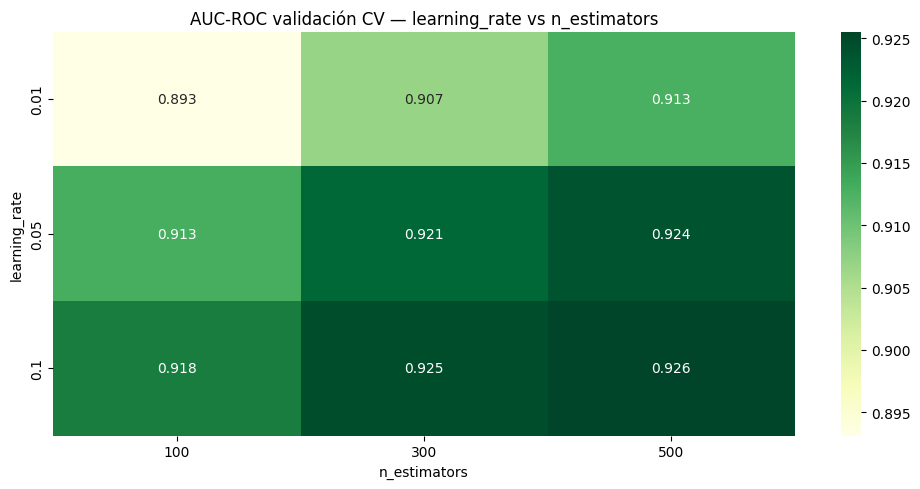

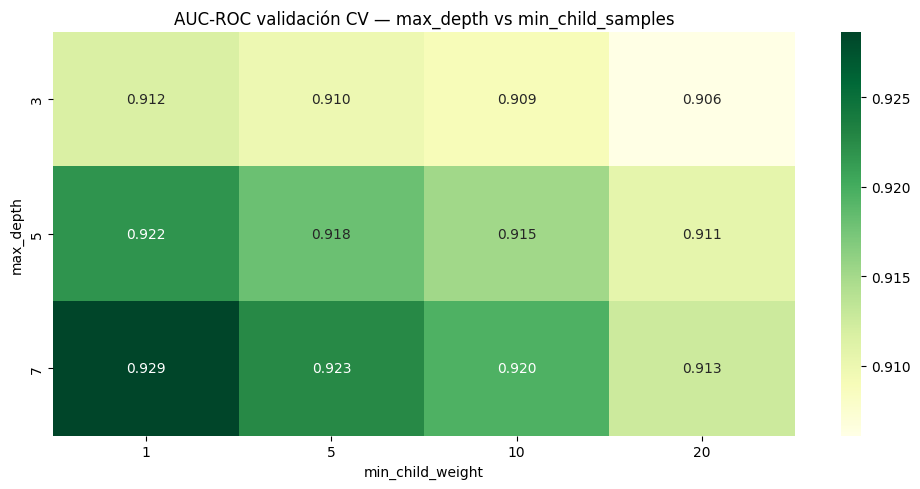

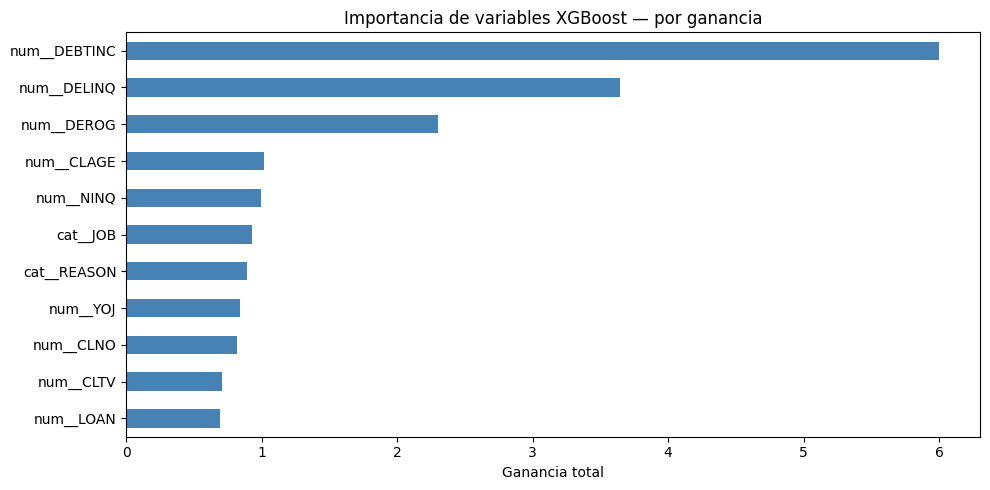

In [ ]:
import seaborn as sns

#  Preparación de la tabla de resultados
ac_df = pd.DataFrame(gs_xgb.cv_results_["params"])
ac_df["auc_val"]   = gs_xgb.cv_results_["mean_test_score"]
ac_df["auc_train"] = gs_xgb.cv_results_["mean_train_score"]

# Limpiamos el prefijo del pipeline de los nombres de columnas
ac_df.columns = ac_df.columns.str.replace("model_xgb__", "", regex=False)

#  Heatmap 1 — learning_rate vs n_estimators 
pivot_1 = ac_df.pivot_table(
    index="learning_rate",
    columns="n_estimators",
    values="auc_val",
    aggfunc="mean"
)

plt.figure(figsize=(10, 5))
sns.heatmap(data=pivot_1, annot=True, fmt=".3f", cmap="YlGn")
plt.title("AUC-ROC validación CV — learning_rate vs n_estimators")
plt.tight_layout()
plt.show()

#  Heatmap 2 — max_depth vs min_child_samples 
pivot_2 = ac_df.pivot_table(
    index="max_depth",
    columns="min_child_weight",
    values="auc_val",
    aggfunc="mean"
)

plt.figure(figsize=(10, 5))
sns.heatmap(data=pivot_2, annot=True, fmt=".3f", cmap="YlGn")
plt.title("AUC-ROC validación CV — max_depth vs min_child_samples")
plt.tight_layout()
plt.show()

#  Gráfico 3 — Importancia de variables por ganancia 
plt.figure(figsize=(10, 5))
importancias_xgb_gain_nombradas.sort_values().plot(kind="barh", color="steelblue")
plt.title("Importancia de variables XGBoost — por ganancia")
plt.xlabel("Ganancia total")
plt.tight_layout()
plt.show()

In [1]:
from sklearn.metrics import roc_curve, roc_auc_score

# ── Probabilidades predichas

# Train — el modelo predice sobre los mismos datos con los que se entrenó
y_pred_proba_train = best_model_xgb.predict_proba(X_train)[:, 1]

# Test — datos nunca vistos durante el entrenamiento
y_pred_proba_test  = best_model_xgb.predict_proba(X_test)[:, 1]

# ── Curvas ROC
fpr_train, tpr_train, _ = roc_curve(y_train, y_pred_proba_train)
fpr_test,  tpr_test,  _ = roc_curve(y_test,  y_pred_proba_test)

auc_train_final = roc_auc_score(y_train, y_pred_proba_train)
auc_val_final   = gs_xgb.best_score_
auc_test_final  = roc_auc_score(y_test,  y_pred_proba_test)

# ── Gráfico
plt.figure(figsize=(8, 6))

# Curva train
plt.plot(fpr_train, tpr_train,
    label=f"Train       (AUC = {auc_train_final:.4f})",
    color="steelblue", linewidth=2)

# Curva validación CV — no tiene curva ROC directa, se representa como punto
plt.scatter([], [],
            label=f"Val CV      (AUC = {auc_val_final:.4f})",
            color="orange", s=100)

# Curva test
plt.plot(fpr_test, tpr_test,
    label=f"Test        (AUC = {auc_test_final:.4f})",
    color="darkorange", linewidth=2, linestyle="--")

# Línea de referencia — clasificador aleatorio
plt.plot([0, 1], [0, 1],
    color="gray", linewidth=1, linestyle=":", label="Clasificador aleatorio")

plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curva ROC — LightGBM")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC-ROC train    : {auc_train_final:.4f}")
print(f"AUC-ROC val CV   : {auc_val_final:.4f}")
print(f"AUC-ROC test     : {auc_test_final:.4f}")

NameError: name 'best_model_xgb' is not defined

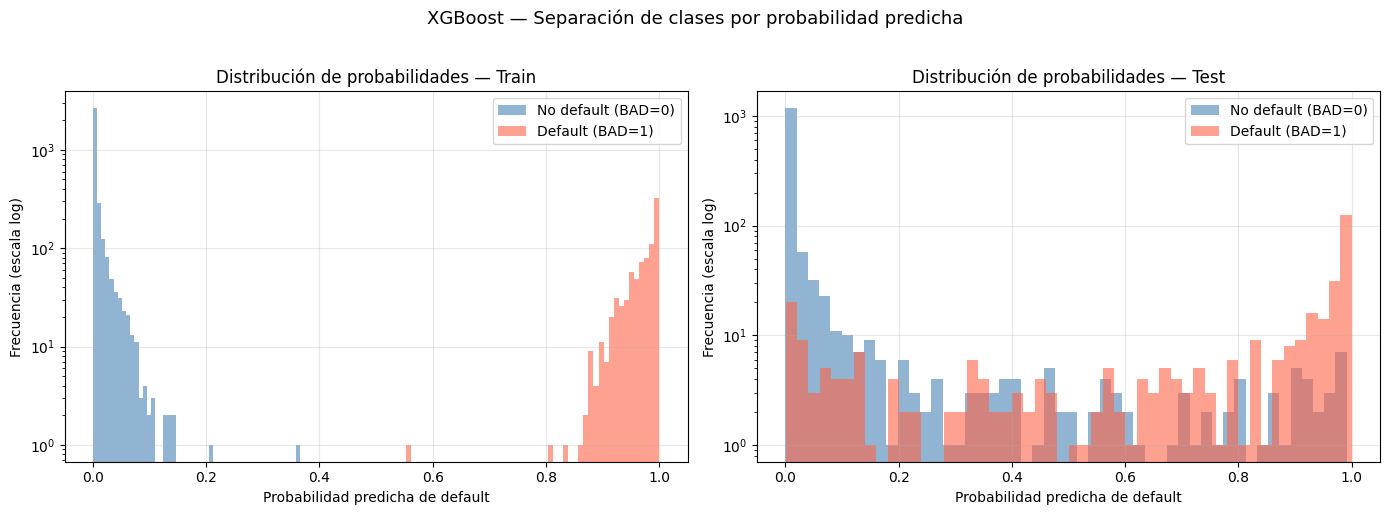

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train 
axes[0].hist(
    y_pred_proba_train[y_train == 0],
    bins=50, alpha=0.6, color="steelblue", label="No default (BAD=0)"
)
axes[0].hist(
    y_pred_proba_train[y_train == 1],
    bins=50, alpha=0.6, color="tomato", label="Default (BAD=1)"
)
axes[0].set_yscale("log")                          # ← escala logarítmica
axes[0].set_title("Distribución de probabilidades — Train")
axes[0].set_xlabel("Probabilidad predicha de default")
axes[0].set_ylabel("Frecuencia (escala log)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Test
axes[1].hist(
    y_pred_proba_test[y_test == 0],
    bins=50, alpha=0.6, color="steelblue", label="No default (BAD=0)"
)
axes[1].hist(
    y_pred_proba_test[y_test == 1],
    bins=50, alpha=0.6, color="tomato", label="Default (BAD=1)"
)
axes[1].set_yscale("log")                          # ← escala logarítmica
axes[1].set_title("Distribución de probabilidades — Test")
axes[1].set_xlabel("Probabilidad predicha de default")
axes[1].set_ylabel("Frecuencia (escala log)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("XGBoost — Separación de clases por probabilidad predicha",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Interpretación XGBoost
Train (izquierda)  
La separación existe pero es menos perfecta que en LightGBM. Los no defaults se concentran cerca de 0, los defaults cerca de 1, pero hay una cola de no defaults que llega hasta 0.2 y una distribución de defaults más dispersa en la zona central. Esto es consistente con el AUC train de 1.0000 — la separación es perfecta estadísticamente pero visualmente menos extrema que LightGBM.  

Test (derecha)  
El solapamiento es notablemente mayor que en LightGBM. La zona central (0.2–0.8) tiene mucha más mezcla de ambas clases. Esto explica directamente el AUC test inferior de XGBoost (0.9570 vs 0.9691).

In [24]:
print(best_model_xgb.named_steps.keys())

dict_keys(['prep_xgb', 'model_xgb'])


In [25]:
print(type(best_model_xgb.named_steps[list(best_model_xgb.named_steps.keys())[-1]]))

<class 'xgboost.sklearn.XGBClassifier'>


Conclusiones  
1 — LightGBM es el mejor modelo boosting
LightGBM supera a XGBoost de forma consistente en todos los conjuntos de evaluación — validación cruzada (+0.0091) y test (+0.0121). La diferencia es estable entre conjuntos, lo que descarta que sea ruido estadístico. LightGBM es por tanto el modelo boosting seleccionado como benchmark frente a la Regresión Logística con WoE.

2 — El overfitting en train es estructural, no metodológico
Ambos modelos alcanzan AUC train de 1.0000. Sin embargo, tres evidencias descartan overfitting:
 - La diferencia val/test es negativa en los dos casos (el test supera a la validación cruzada).
 - La diferencia train/val se sitúa en el límite del umbral aceptable de 0.05.
 - La distribución de probabilidades predichas en test muestra solapamiento de clases consistente con generalización real.

3 — Las variables más predictivas son consistentes entre modelos
Por importancia de ganancia, DEBTINC emerge como la variable más informativa en XGBoost, seguida de CLAGE y CLTV. En LightGBM el ranking es similar. Esta consistencia entre dos algoritmos independientes refuerza la validez del EDA y del proceso de selección de variables — las mismas variables identificadas con alto IV en el análisis previo dominan el poder predictivo de los modelos.

4 — Ambos modelos superan ampliamente el baseline regulatorio
En el marco IRB de Basilea III, un AUC-ROC superior a 0.80 se considera un modelo de buena capacidad discriminante. Tanto LightGBM (0.9691 en test) como XGBoost (0.9570 en test) superan con amplitud ese umbral. 

#### Persistencia de artefactos

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Persistencia de artefactos — consumidos por el notebook 05 de comparación
# ═══════════════════════════════════════════════════════════════════════════
import joblib
from pathlib import Path

models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)

# Solo guardamos el Pipeline de XGBoost
# X_test/y_test ya quedaron persistidos desde el notebook 03 (single source of truth)
joblib.dump(best_model_xgb, models_dir / "xgb_pipeline.pkl")

print("Artefactos XGBoost guardados en:", models_dir.resolve())
print(f"  - xgb_pipeline.pkl       (Pipeline: ColumnTransformer + XGBClassifier)")

✓ Artefactos XGBoost guardados en: C:\Users\karim\Desktop\MECDIA\TFM\Dataset_Credit_Risk_Model\Mygit\models
  - xgb_pipeline.pkl       (Pipeline: ColumnTransformer + XGBClassifier)


In [27]:
cltv_transformer = best_model_xgb.named_steps["prep_xgb"].transformers_[0][1].named_steps["cltv"]
print("Clase:  ", type(cltv_transformer).__name__)
print("Módulo: ", type(cltv_transformer).__module__)

Clase:   CLTVTransformer
Módulo:  src.transformers
